**Name: Rudra P Patel**



**Roll No.: 25MCE023**

**Practical-1: Analysis of Titanic – Machine Learning from Disaster**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path_train = '/content/drive/MyDrive/Colab Notebooks/Files/DL/Prac1/train.csv'
file_path_test = '/content/drive/MyDrive/Colab Notebooks/Files/DL/Prac1/test.csv'

df = pd.read_csv(file_path_train)
df.head()

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


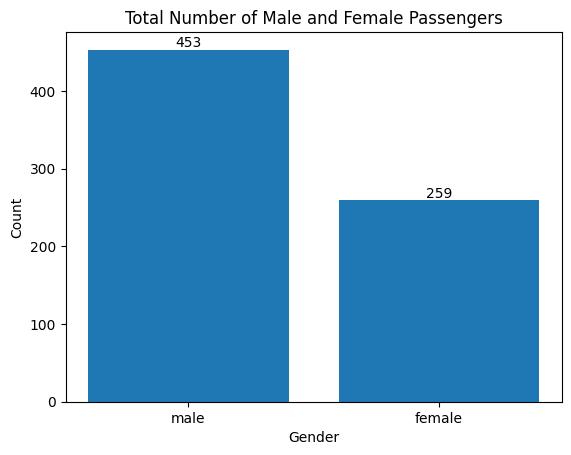

In [ ]:
# finding the number of males and females

df.columns = [c.strip().lower() for c in df.columns]

# here preprocessing id done
df = df.dropna(subset=['age', 'embarked', 'pclass', 'survived'])

genderCount = df['sex'].value_counts()
# print(genderCount)


plt.figure()
bars = plt.bar(genderCount.index, genderCount.values)

plt.title("Total Number of Male and Female Passengers")
plt.xlabel("Gender")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.show()

survived    0    1
sex               
female     64  195
male      360   93


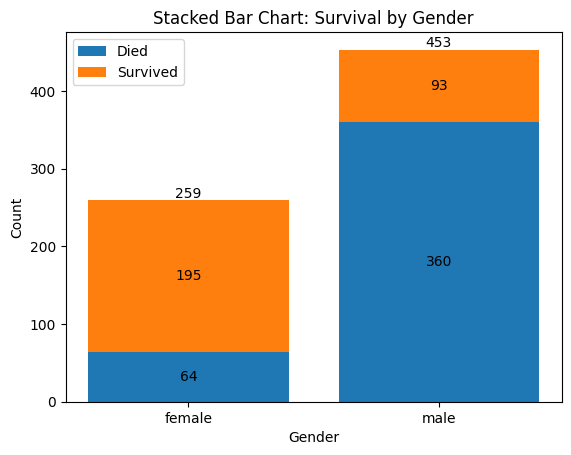

In [ ]:
# count of males and females with the surival count and died count of respective gender
import pandas as pd
import matplotlib.pyplot as plt

df2 = pd.read_csv(file_path_train)

df2.columns = [c.strip().lower() for c in df.columns]
df2 = df2.dropna(subset=['age', 'embarked', 'pclass', 'survived'])

# fidnng the count
counts2 = df2.groupby(['sex', 'survived']).size().unstack(fill_value=0)
print(counts2)

genders = counts2.index
died = counts2[0]
survived = counts2[1]


plt.figure()
plt.bar(genders, died, label='Died')
plt.bar(genders, survived, bottom=died, label='Survived')

plt.title("Stacked Bar Chart: Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend()

for i in range(len(genders)):
    plt.text(
        i,
        died.iloc[i] / 2,
        died.iloc[i],
        ha='center',
        va='center'
    )

    plt.text(
        i,
        died.iloc[i] + survived.iloc[i] / 2,
        survived.iloc[i],
        ha='center',
        va='center'
    )

    total = died.iloc[i] + survived.iloc[i]
    plt.text(
        i,
        total,
        f"{total}",
        ha='center',
        va='bottom'
    )

plt.show()


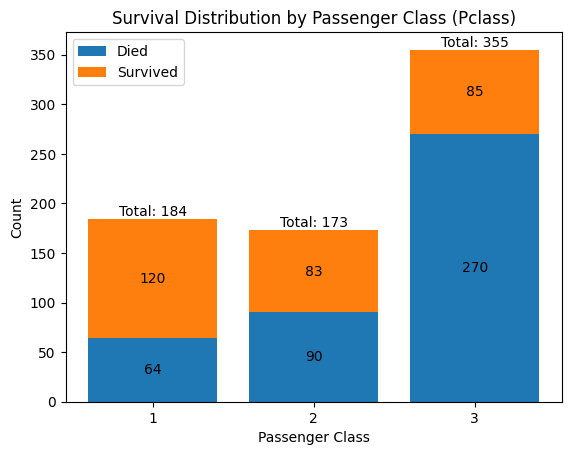

In [ ]:
# here we are counting the number of people which have respective class and are died or survived
counts = df2.groupby(['pclass', 'survived']).size().unstack(fill_value=0)

classes = counts.index.astype(str)
died = counts[0]
survived = counts[1]

plt.figure()
plt.bar(classes, died, label='Died')
plt.bar(classes, survived, bottom=died, label='Survived')

plt.title("Survival Distribution by Passenger Class (Pclass)")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend()

for i in range(len(classes)):
    plt.text(i, died.iloc[i] / 2, died.iloc[i], ha='center', va='center')

    plt.text(
        i,
        died.iloc[i] + survived.iloc[i] / 2,
        survived.iloc[i],
        ha='center',
        va='center'
    )

    total = died.iloc[i] + survived.iloc[i]
    plt.text(i, total, f"Total: {total}", ha='center', va='bottom')

plt.show()


/tmp/ipykernel_715/2974425229.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['age_group', 'survived']).size().unstack(fill_value=0)


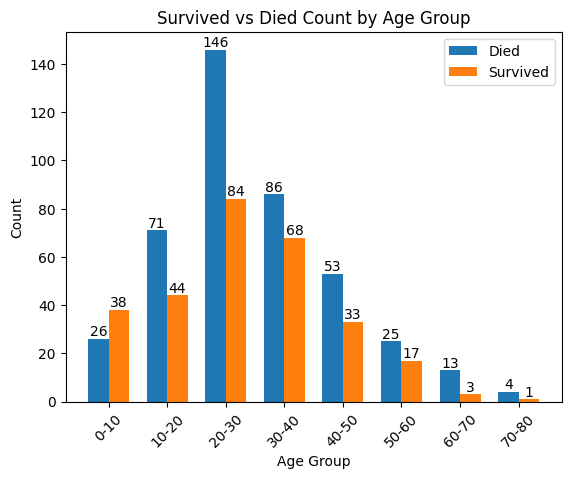

In [ ]:
# classification wrt the age range

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file_path_train)

df.columns = [c.strip().lower() for c in df.columns]

# df = df.dropna(subset=['age'])
df = df.dropna(subset=['age', 'embarked', 'pclass', 'survived'])

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

counts = df.groupby(['age_group', 'survived']).size().unstack(fill_value=0)

age_groups = counts.index
died = counts[0]
survived = counts[1]

x = np.arange(len(age_groups))
width = 0.35

plt.figure()
plt.bar(x - width/2, died, width, label='Died')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Survived vs Died Count by Age Group")
plt.xticks(x, age_groups, rotation=45)
plt.legend()

for i in range(len(age_groups)):
    plt.text(x[i] - width/2, died.iloc[i], died.iloc[i], ha='center', va='bottom')
    plt.text(x[i] + width/2, survived.iloc[i], survived.iloc[i], ha='center', va='bottom')

plt.show()


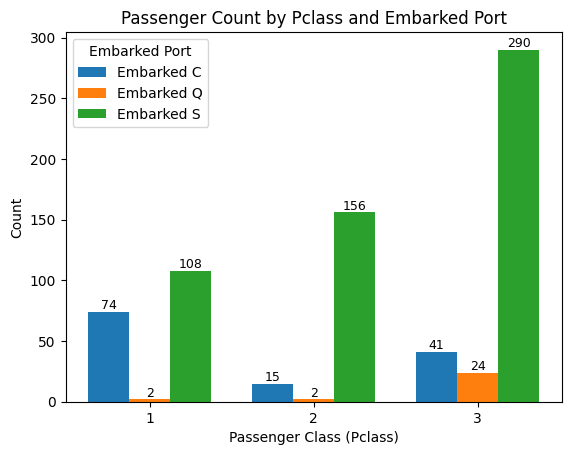

In [ ]:
# embarked and the ticket they have, helps us to see that the rich peoples or u can say wealthy peoples must be leaving in which city

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file_path_train)


df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=['age', 'embarked', 'pclass', 'survived'])
# df = df.dropna(subset=['embarked'])

counts = df.groupby(['pclass', 'embarked']).size().unstack(fill_value=0)

pclasses = counts.index.astype(str)
embarked_ports = counts.columns

x = np.arange(len(pclasses))
width = 0.25

plt.figure()

for i, port in enumerate(embarked_ports):
    plt.bar(x + i*width - width, counts[port], width, label=f'Embarked {port}')

plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Count")
plt.title("Passenger Count by Pclass and Embarked Port")
plt.xticks(x, pclasses)
plt.legend(title="Embarked Port")

for i, port in enumerate(embarked_ports):
    for j, val in enumerate(counts[port]):
        plt.text(
            j + i*width - width,
            val,
            val,
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.show()


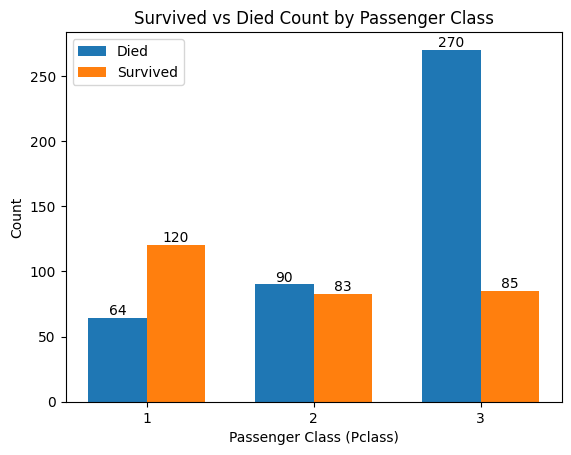

In [ ]:
# pclass seats and the died and servived plots helps us to see the number os people having 1st class are servived more compare to the other class seats \
# SAME IT IS DONE++++++++++++++++++++++++++ XXXXXXXXXXXXXXXXXXXXXXXXXXXX

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file_path_train)

df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=['age', 'embarked', 'pclass', 'survived'])

counts = df.groupby(['pclass', 'survived']).size().unstack(fill_value=0)

pclasses = counts.index.astype(str)
died = counts[0]
survived = counts[1]

x = np.arange(len(pclasses))
width = 0.35

plt.figure()
plt.bar(x - width/2, died, width, label='Died')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Count")
plt.title("Survived vs Died Count by Passenger Class")
plt.xticks(x, pclasses)
plt.legend()

for i in range(len(pclasses)):
    plt.text(x[i] - width/2, died.iloc[i], died.iloc[i],
             ha='center', va='bottom')
    plt.text(x[i] + width/2, survived.iloc[i], survived.iloc[i],
             ha='center', va='bottom')

plt.show()


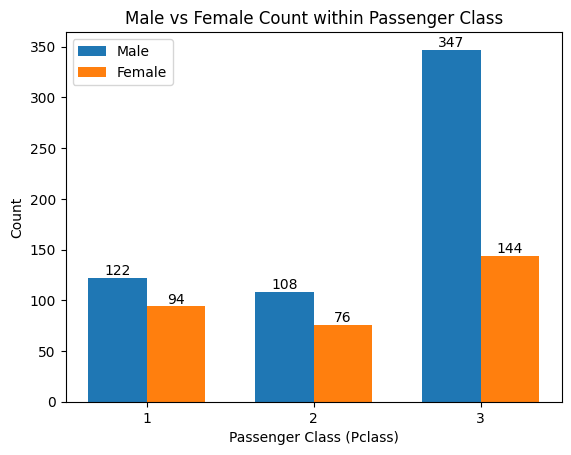

In [ ]:
# gender seats in seats class

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file_path_train)

df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=['sex', 'pclass'])

counts = df.groupby(['pclass', 'sex']).size().unstack(fill_value=0)

pclasses = counts.index.astype(str)
male = counts['male']
female = counts['female']

x = np.arange(len(pclasses))
width = 0.35

plt.figure()
plt.bar(x - width/2, male, width, label='Male')
plt.bar(x + width/2, female, width, label='Female')

plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Count")
plt.title("Male vs Female Count within Passenger Class")
plt.xticks(x, pclasses)
plt.legend()

for i in range(len(pclasses)):
    plt.text(x[i] - width/2, male.iloc[i], male.iloc[i],
             ha='center', va='bottom')
    plt.text(x[i] + width/2, female.iloc[i], female.iloc[i],
             ha='center', va='bottom')

plt.show()


how surival is depended on the fare price, higher fare paying people are survived and lower fare paying people are died more.

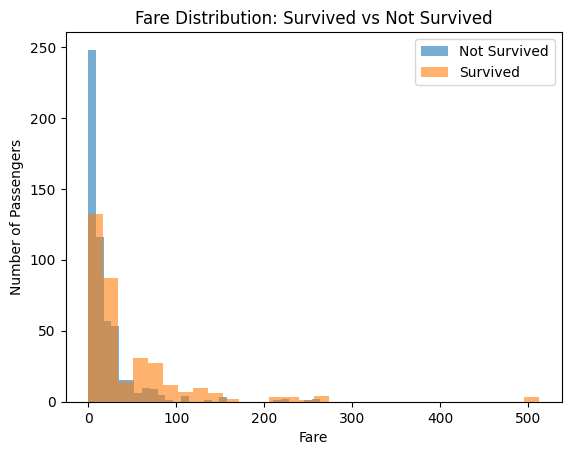

In [ ]:
# survival vs fare analysis

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(file_path_train)

df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=['fare', 'survived'])

survived_fare = df[df['survived'] == 1]['fare']
not_survived_fare = df[df['survived'] == 0]['fare']

plt.figure()

plt.hist(not_survived_fare, bins=30, alpha=0.6, label='Not Survived')
plt.hist(survived_fare, bins=30, alpha=0.6, label='Survived')

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Fare Distribution: Survived vs Not Survived")

plt.legend()
plt.show()



# survivors are more on higher fare side
# deaths concentrated in low fare range


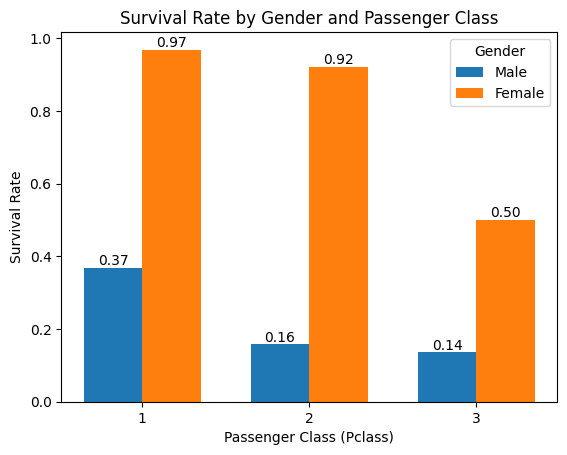

In [ ]:
# survival is strongly influenced by both gender and passenger class.
# Females especially in first class, had the highest survival rates while males in third class had the lowest survival rates.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(file_path_train)

df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=['sex', 'pclass', 'survived'])

counts = df.groupby(['pclass', 'sex', 'survived']).size().unstack(fill_value=0)

counts['total'] = counts[0] + counts[1]
counts['survival_rate'] = counts[1] / counts['total']

male_data = counts.xs('male', level='sex')
female_data = counts.xs('female', level='sex')

pclasses = male_data.index.astype(str)

x = np.arange(len(pclasses))
width = 0.35

plt.figure()

plt.bar(x - width/2, male_data['survival_rate'], width, label='Male')
plt.bar(x + width/2, female_data['survival_rate'], width, label='Female')

plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Gender and Passenger Class")

plt.xticks(x, pclasses)
plt.legend(title="Gender")

for i, val in enumerate(male_data['survival_rate']):
    plt.text(i - width/2, val, f"{val:.2f}", ha='center', va='bottom')

for i, val in enumerate(female_data['survival_rate']):
    plt.text(i + width/2, val, f"{val:.2f}", ha='center', va='bottom')

plt.show()